<a href="https://colab.research.google.com/github/pinnojusaidivya-byte/6714_MDS_LAB/blob/main/week12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('Advertising.csv')
print(df.head())


   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [ ]:
print(df.index)

RangeIndex(start=0, stop=200, step=1)


In [ ]:
col=df.columns.tolist()
print(col)

['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           1.58e-96
Time:                        05:50:12   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

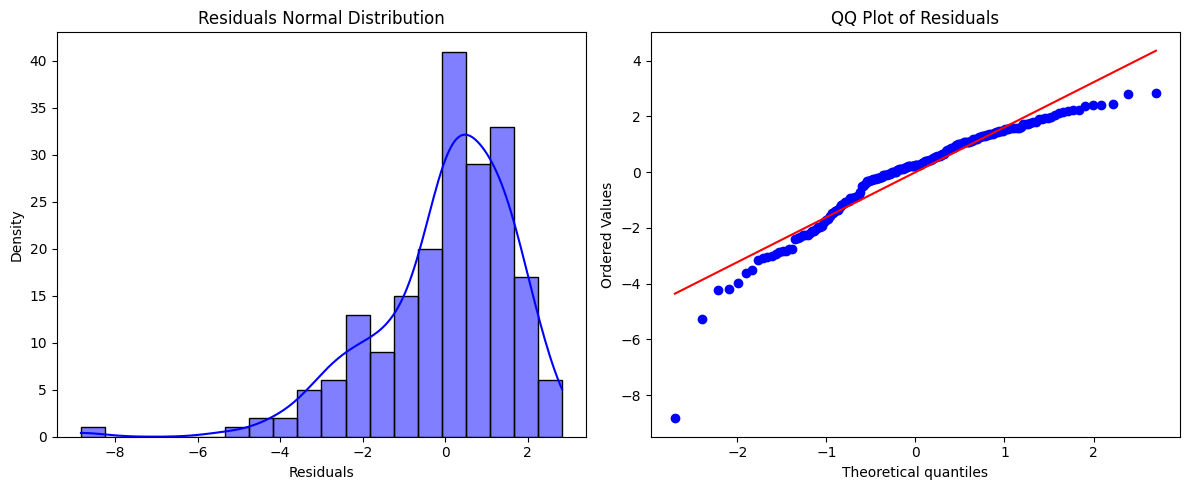

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

# 1. Load the dataset (replace 'advertising.csv' with your file name)
df = pd.read_csv('Advertising.csv')

# 2. Define Features (X) and Target (y)
# We drop 'Unnamed: 0' (index column) and 'Sales' (the target)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Add a constant (intercept) term to the features matrix
X = sm.add_constant(X)

# 3. Fit the Linear Regression Model
model = sm.OLS(y, X).fit()
print(model.summary())  # Prints R-squared, p-values, and coefficients

# Extract the residuals (errors) to check normality
residuals = model.resid

# 4. Diagnostics Visualizations
plt.figure(figsize=(12, 5))

# Plot A: Normal Distribution Histogram of Residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='blue', bins=20)
plt.title('Residuals Normal Distribution')
plt.xlabel('Residuals')
plt.ylabel('Density')

# Plot B: Quantile-Quantile (QQ) Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ Plot of Residuals')

plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
import statsmodels.api as sm

# 1. Load the dataset
df = pd.read_csv('Advertising.csv')

# 2. Define Features (X) and Target (y)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# 3. Add the intercept constant required by statsmodels
X = sm.add_constant(X)

# 4. Fit the Ordinary Least Squares (OLS) model
model = sm.OLS(y, X).fit()

# 5. Extract the Intercept and Slopes
intercept = model.params['const']
slope_tv = model.params['TV']
slope_radio = model.params['Radio']
slope_newspaper = model.params['Newspaper']

# 6. Print the results cleanly
print("--- Regression Coefficients ---")
print(f"Intercept (c):        {intercept:.4f}")
print(f"TV Slope (m1):        {slope_tv:.4f}")
print(f"Radio Slope (m2):     {slope_radio:.4f}")
print(f"Newspaper Slope (m3): {slope_newspaper:.4f}")
print("\n--- Final Linear Equation ---")
print(f"Sales = {intercept:.4f} + ({slope_tv:.4f} * TV) + ({slope_radio:.4f} * Radio) + ({slope_newspaper:.4f} * Newspaper)")


--- Regression Coefficients ---
Intercept (c):        2.9389
TV Slope (m1):        0.0458
Radio Slope (m2):     0.1885
Newspaper Slope (m3): -0.0010

--- Final Linear Equation ---
Sales = 2.9389 + (0.0458 * TV) + (0.1885 * Radio) + (-0.0010 * Newspaper)


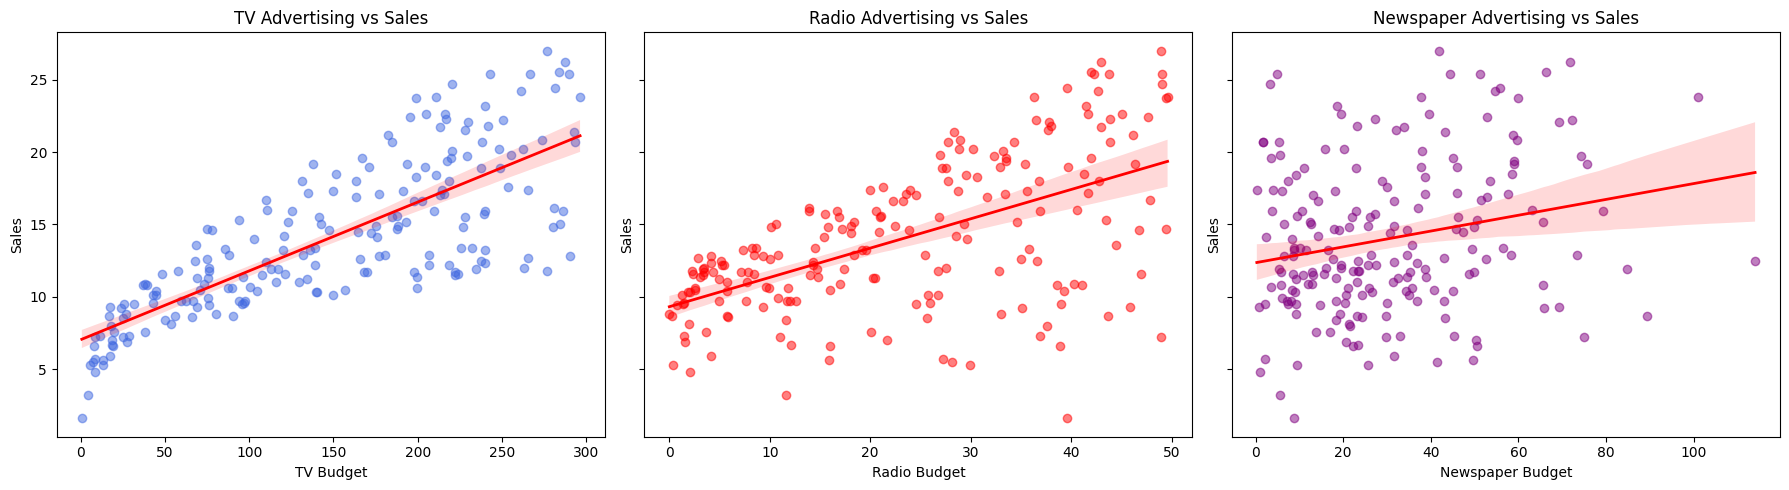

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset


# 2. Set up the plotting grid (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# 3. Plot TV vs Sales with its regression line
sns.regplot(x='TV', y='Sales', data=df, ax=axes[0],
            color='royalblue', scatter_kws={'alpha':0.5}, line_kws={'color':'red', 'lw':2})
axes[0].set_title('TV Advertising vs Sales')
axes[0].set_xlabel('TV Budget')
axes[0].set_ylabel('Sales')

# 4. Plot Radio vs Sales with its regression line
sns.regplot(x='Radio', y='Sales', data=df, ax=axes[1],
            color='red', scatter_kws={'alpha':0.5}, line_kws={'color':'red', 'lw':2})
axes[1].set_title('Radio Advertising vs Sales')
axes[1].set_xlabel('Radio Budget')

# 5. Plot Newspaper vs Sales with its regression line
sns.regplot(x='Newspaper', y='Sales', data=df, ax=axes[2],
            color='purple', scatter_kws={'alpha':0.5}, line_kws={'color':'red', 'lw':2})
axes[2].set_title('Newspaper Advertising vs Sales')
axes[2].set_xlabel('Newspaper Budget')

# 6. Adjust layout and show the charts
plt.tight_layout()
plt.show()


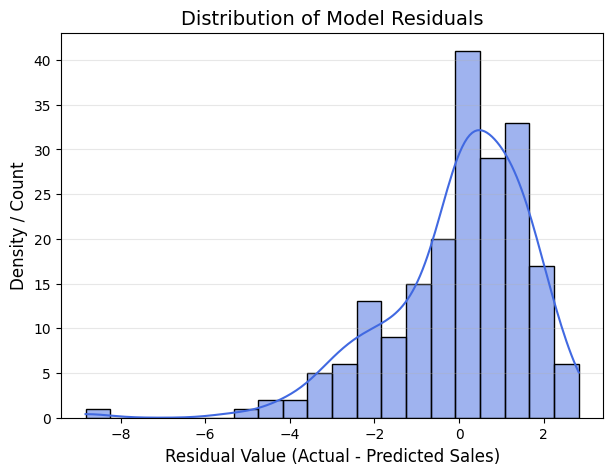

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. Load data and fit model to get residuals
df = pd.read_csv('Advertising.csv')
X = sm.add_constant(df[['TV', 'Radio', 'Newspaper']])
y = df['Sales']
model = sm.OLS(y, X).fit()
residuals = model.resid  # Extracting the errors

# 2. Plot the distribution histogram
plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True, color='royalblue', bins=20)

# 3. Aesthetics
plt.title('Distribution of Model Residuals', fontsize=14)
plt.xlabel('Residual Value (Actual - Predicted Sales)', fontsize=12)
plt.ylabel('Density / Count', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()


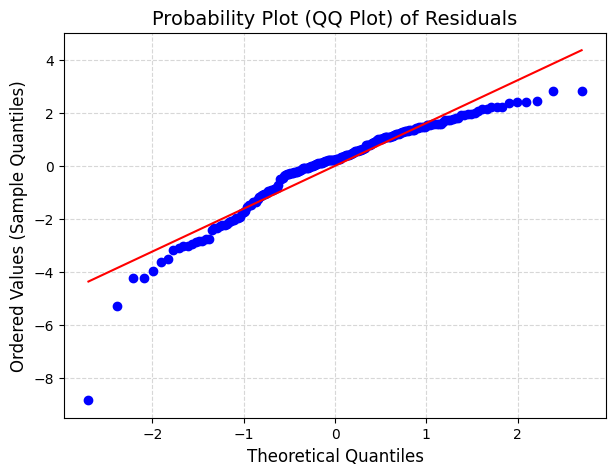

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

# 1. Load data and fit model to get residuals
df = pd.read_csv('Advertising.csv')
X = sm.add_constant(df[['TV', 'Radio', 'Newspaper']])
y = df['Sales']
model = sm.OLS(y, X).fit()
residuals = model.resid  # Extracting the errors

# 2. Generate the QQ Plot
plt.figure(figsize=(7, 5))
stats.probplot(residuals, dist="norm", plot=plt)

# 3. Aesthetics customization
plt.title('Probability Plot (QQ Plot) of Residuals', fontsize=14)
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Ordered Values (Sample Quantiles)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()
